# LOAD LIBRARIES

In [14]:
import os
import math
import numpy as np
import scipy
import pandas as pd # pandas allows to do a lot of basic data manipulation such as loading csv data files
from datetime import datetime
import matplotlib.pyplot as plt # matplotlib is a basic ploting library of Python
import scipy.stats as stats
import sys
import matplotlib.dates as mdates
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import r2_score

In [15]:
# Project settings (dataset period, data paths): see src/config.py
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.config import DATA_DIR, PERIOD_START, PERIOD_END, select_period
print(f"Dataset period: {PERIOD_START} to {PERIOD_END} (CET, UTC+1)")

Dataset period: 2023-10-17 00:00:00 to 2024-08-23 00:00:00 (CET, UTC+1)


# READ DATA

## STATION DATA

select_period: kept 12873 of 26601 records (2023-11-18 23:30:00+01:00 to 2024-08-23 00:00:00+01:00, timestamp=end)


,g,pa,ppfd,prec,rh,swc_0.05,swc_0.15,swc_0.3,swc_0.05_soilvue,swc_0.1_soilvue,...,ts_0.05_soilvue,ts_0.1_soilvue,ts_0.2_soilvue,ts_0.3_soilvue,ts_0.4_soilvue,ts_0.5_soilvue,sw_in,sw_out,lw_in,lw_out
TIMESTAMP_END,,,,,,,,,,,,,,,,,,,,,
2023-11-18 23:30:00+01:00,-4.175582,95.558519,NaN,0.000,78.492593,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2023-11-19 00:00:00+01:00,-3.701263,95.507667,NaN,0.000,79.276667,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2023-11-19 00:30:00+01:00,-2.279430,95.470000,NaN,0.221,84.429999,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2023-11-19 01:00:00+01:00,-0.730810,95.467667,NaN,0.153,87.846667,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2023-11-19 01:30:00+01:00,0.000000,95.466667,NaN,0.204,89.633334,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 22:00:00+01:00,-26.544846,95.235333,0.0,0.000,84.016666,14.569232,25.346449,23.025461,2.298719,2.191173,...,19.214078,20.279098,20.453949,20.210720,19.699012,19.550167,0.0,0.0,298.491030,375.988470
2024-08-22 22:30:00+01:00,-26.996622,95.232667,0.0,0.000,87.603334,14.516813,25.346746,23.027684,2.216420,2.205174,...,18.847740,19.991153,20.362207,20.210720,19.721734,19.552880,0.0,0.0,297.902023,375.429693
2024-08-22 23:00:00+01:00,-26.066041,95.225333,0.0,0.000,87.666666,14.474849,25.327557,23.022387,2.199119,2.161226,...,18.566035,19.735453,20.263314,20.210720,19.742679,19.560131,0.0,0.0,298.232693,375.854200


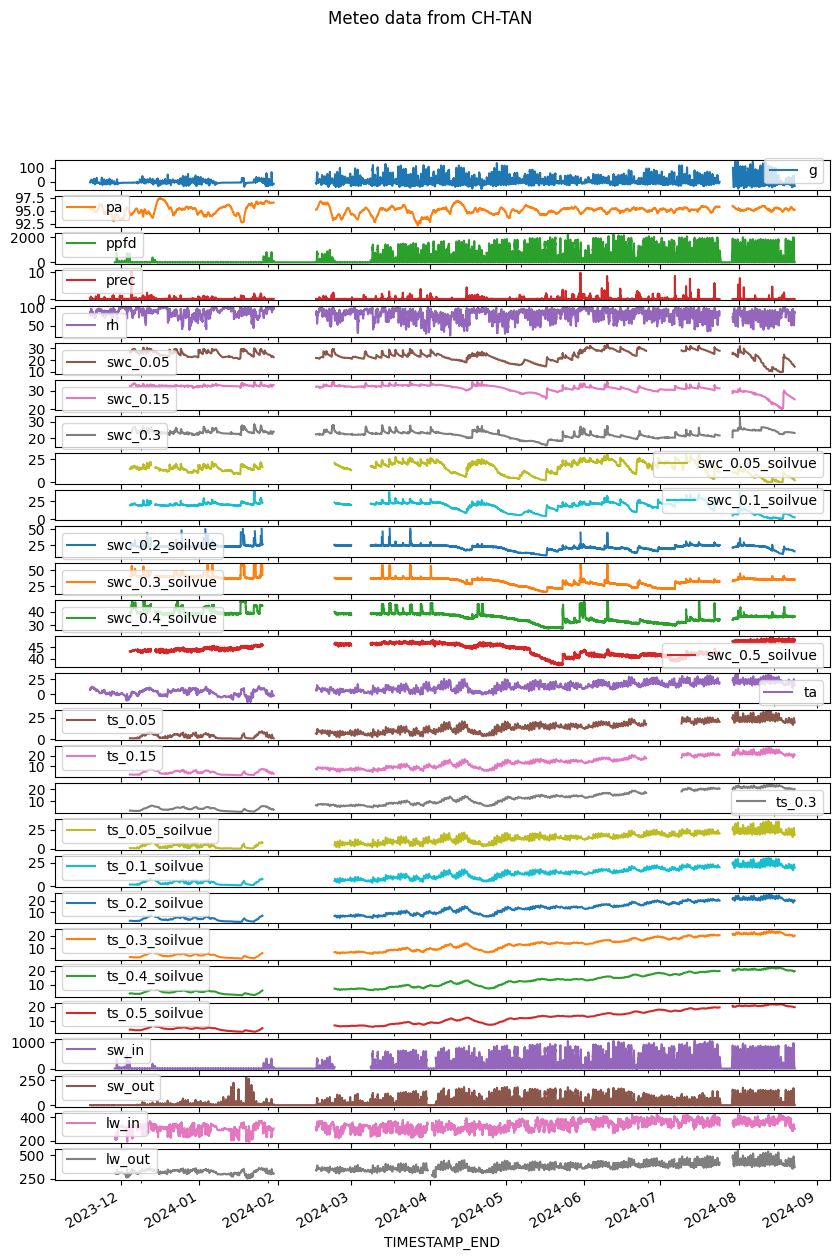

In [16]:
meteo = pd.read_csv('11.1_CH-TAN_meteo_meteoscreening_diive.csv')
meteo['TIMESTAMP_END'] = pd.to_datetime(meteo['TIMESTAMP_END'], format='%Y-%m-%d %H:%M:%S')
meteo.set_index('TIMESTAMP_END', inplace=True)
meteo.index = meteo.index.tz_localize('Etc/GMT-1')
meteo = select_period(meteo, timestamp='end')  # restrict to the dataset period
meteo.plot(subplots=True, x_compat=True, figsize=(10, 15), title='Meteo data from CH-TAN');
meteo

## METEOSWISS DATA

- tre200s0 --> TA at 2 m in °C
- ure200s0 --> RH at 2m
- prestas0 --> PA in hPa
- fve010z0 --> WS in m/s vectorial mean
- fkl010z0 --> WS in m/s scalar mean
- dkl010z0 --> WD in degrees
- rre150z0 --> P in mm
- gre000z0 --> global radiation in w/m2
- ods000z0 --> diffuse radiation in w/m2
- oli000z0 --> LW_IN in w/m2
- olo000z0 --> LW_OUT in w/m2
- osr000z0 --> SW_OUT in w/m2

select_period: kept 14928 of 14933 records (2023-10-17 00:30:00+01:00 to 2024-08-23 00:00:00+01:00, timestamp=end)


,TA,RH,PA,PREC,SW_IN,SW_OUT,LW_IN,LW_OUT
timestamp,,,,,,,,
2023-10-17 00:30:00+01:00,1.966667,94.800000,95.490000,0.0,1.666667,-6.0,248.666667,306.333333
2023-10-17 01:00:00+01:00,1.966667,95.100000,95.483333,0.0,1.333333,-6.0,250.333333,305.666667
2023-10-17 01:30:00+01:00,1.566667,94.966667,95.453333,0.0,1.000000,-6.0,255.333333,304.666667
2023-10-17 02:00:00+01:00,1.266667,94.366667,95.430000,0.0,1.333333,-6.0,252.000000,303.666667
2023-10-17 02:30:00+01:00,1.400000,95.600000,95.426667,0.0,1.333333,-6.0,252.666667,303.666667
...,...,...,...,...,...,...,...,...
2024-08-22 22:00:00+01:00,14.566667,88.966667,95.256667,0.0,1.666667,-2.0,316.000000,374.333333
2024-08-22 22:30:00+01:00,14.433333,88.633333,95.256667,0.0,1.333333,-2.0,315.333333,371.000000
2024-08-22 23:00:00+01:00,14.266667,89.233333,95.246667,0.0,1.333333,-2.0,315.000000,371.333333


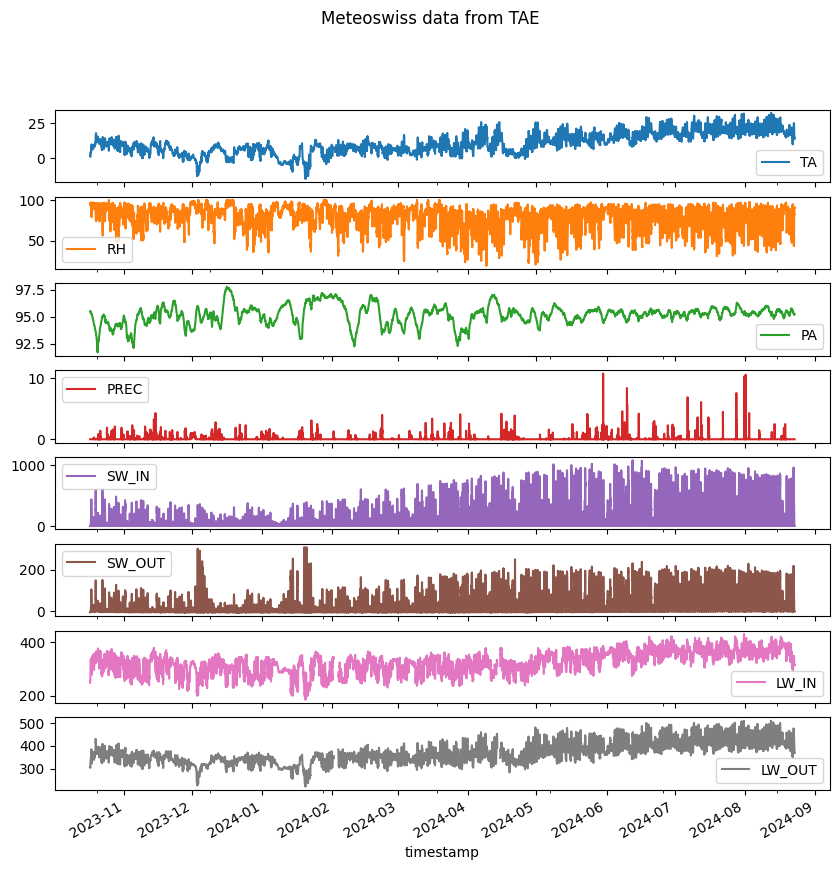

In [17]:
meteoswiss = pd.read_csv(Path('meteoswiss') / 'meteoswiss_TAE_meteo_2020-2029.csv', delimiter=';')
meteoswiss_2025 = pd.read_csv(Path('meteoswiss') / 'meteoswiss_TAE_meteo_2025.csv', delimiter=';')
meteoswiss = pd.concat([meteoswiss, meteoswiss_2025], ignore_index=True)
rename_dict = {
    'reference_timestamp': 'timestamp',
    'tre200s0': 'TA',
    'ure200s0': 'RH',
    'prestas0': 'PA',
    'rre150z0': 'PREC',
    'gre000z0': 'SW_IN',
    'osr000z0': 'SW_OUT',
    'oli000z0': 'LW_IN',
    'olo000z0': 'LW_OUT',
}
meteoswiss.rename(columns=rename_dict, inplace=True)
meteoswiss = meteoswiss[[col for col in rename_dict.values()]]
meteoswiss['timestamp'] = pd.to_datetime(meteoswiss['timestamp'], format='%d.%m.%Y %H:%M')
meteoswiss.set_index('timestamp', inplace=True)
# Convert meteoswiss timestamps to UTC+1
meteoswiss.index = meteoswiss.index.tz_localize('UTC').tz_convert('Etc/GMT-1')

# Change unit for atmospheric pressure from hPa to kgPa
meteoswiss['PA'] = meteoswiss['PA'] / 10.0  # Convert hPa to kPa

# Restrict to the dataset period (1 h margin so that the first 30-min means are complete)
meteoswiss = meteoswiss[str(PERIOD_START - pd.Timedelta('1h')):str(PERIOD_END + pd.Timedelta('1h'))]

# Resample 10-min to 30-min, summing 'PREC' and averaging other columns
meteoswiss = meteoswiss.resample('30min', label='right', closed='right').agg({
    'TA': 'mean',
    'RH': 'mean',
    'PA': 'mean',
    'PREC': 'sum',
    'SW_IN': 'mean',
    'SW_OUT': 'mean',
    'LW_IN': 'mean',
    'LW_OUT': 'mean'
})
meteoswiss = select_period(meteoswiss, timestamp='end')  # drop the margin again

meteoswiss.plot(subplots=True, x_compat=True, figsize=(10, 10), title='Meteoswiss data from TAE');
meteoswiss

Linear model to calculate ppfd from sw_in because it was not measured by Meteoswiss

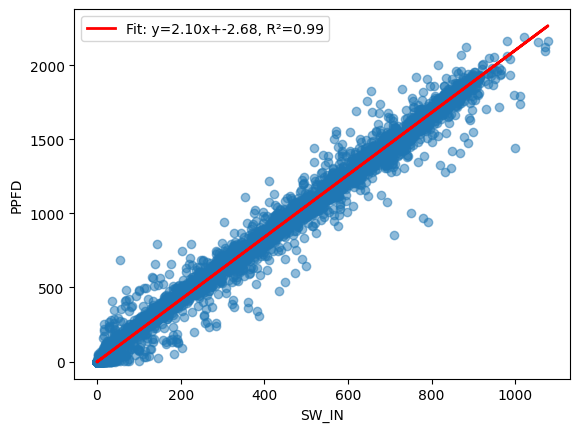

In [18]:
# Align the two series by index (inner join keeps only common timestamps)
df = meteoswiss[['SW_IN']].join(meteo[['ppfd']], how='inner')

# Drop NaNs
df = df.dropna()

x = df['SW_IN'].values.reshape(-1, 1)
y = df['ppfd'].values

# Fit robust regression
model = HuberRegressor().fit(x, y)
y_pred = model.predict(x)

# Equation and R²
slope = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y, y_pred)

# Plot
plt.scatter(x, y, alpha=0.5)
plt.plot(x, y_pred, color="red", lw=2, label=f"Fit: y={slope:.2f}x+{intercept:.2f}, R²={r2:.2f}")
plt.xlabel('SW_IN')
plt.ylabel('PPFD')
plt.legend()
plt.show()

# Create a new PPFD col using the linear model
meteoswiss['PPFD'] = model.predict(meteoswiss['SW_IN'].values.reshape(-1, 1))

## MERGE

In [19]:
meteo_merged = pd.merge(meteo, meteoswiss, left_index=True, right_index=True, how='outer')

meteo_merged

,g,pa,ppfd,prec,rh,swc_0.05,swc_0.15,swc_0.3,swc_0.05_soilvue,swc_0.1_soilvue,...,lw_out,TA,RH,PA,PREC,SW_IN,SW_OUT,LW_IN,LW_OUT,PPFD
2023-10-17 00:30:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.966667,94.800000,95.490000,0.0,1.666667,-6.0,248.666667,306.333333,0.822223
2023-10-17 01:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.966667,95.100000,95.483333,0.0,1.333333,-6.0,250.333333,305.666667,0.120793
2023-10-17 01:30:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.566667,94.966667,95.453333,0.0,1.000000,-6.0,255.333333,304.666667,-0.580637
2023-10-17 02:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.266667,94.366667,95.430000,0.0,1.333333,-6.0,252.000000,303.666667,0.120793
2023-10-17 02:30:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.400000,95.600000,95.426667,0.0,1.333333,-6.0,252.666667,303.666667,0.120793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 22:00:00+01:00,-26.544846,95.235333,0.0,0.0,84.016666,14.569232,25.346449,23.025461,2.298719,2.191173,...,375.988470,14.566667,88.966667,95.256667,0.0,1.666667,-2.0,316.000000,374.333333,0.822223
2024-08-22 22:30:00+01:00,-26.996622,95.232667,0.0,0.0,87.603334,14.516813,25.346746,23.027684,2.216420,2.205174,...,375.429693,14.433333,88.633333,95.256667,0.0,1.333333,-2.0,315.333333,371.000000,0.120793
2024-08-22 23:00:00+01:00,-26.066041,95.225333,0.0,0.0,87.666666,14.474849,25.327557,23.022387,2.199119,2.161226,...,375.854200,14.266667,89.233333,95.246667,0.0,1.333333,-2.0,315.000000,371.333333,0.120793
2024-08-22 23:30:00+01:00,-26.467619,95.219667,0.0,0.0,89.426667,14.413858,25.321830,23.013035,2.186805,2.130850,...,372.103287,13.633333,90.966667,95.250000,0.0,1.666667,-2.0,315.666667,370.333333,0.822223


# COMPARE DATASETS

During winter time

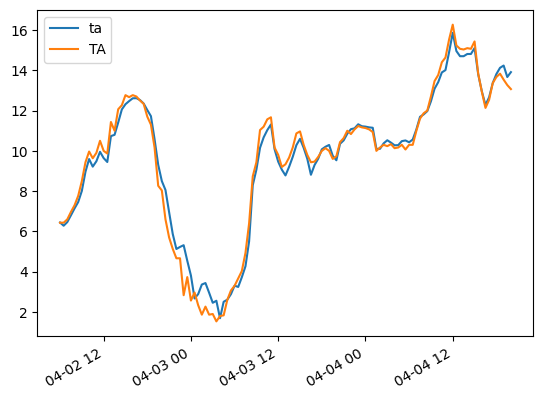

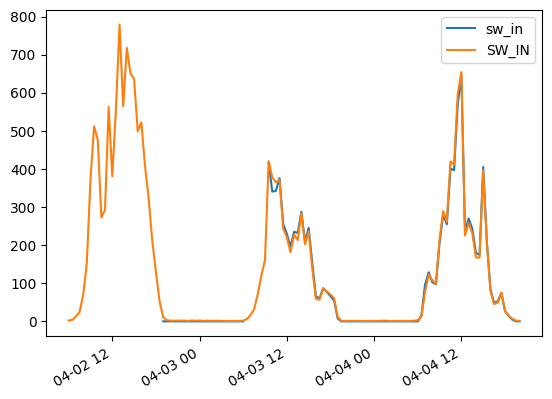

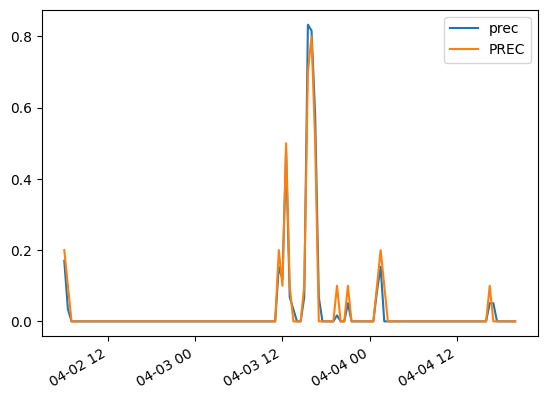

In [20]:
start_date = '2024-04-02 06:00'
end_date = '2024-04-04 20:00'
meteo_merged[start_date:end_date][['ta', 'TA']].plot(x_compat=True);
meteo_merged[start_date:end_date][['sw_in', 'SW_IN']].plot(x_compat=True);
meteo_merged[start_date:end_date][['prec', 'PREC']].plot(x_compat=True);

During summer time

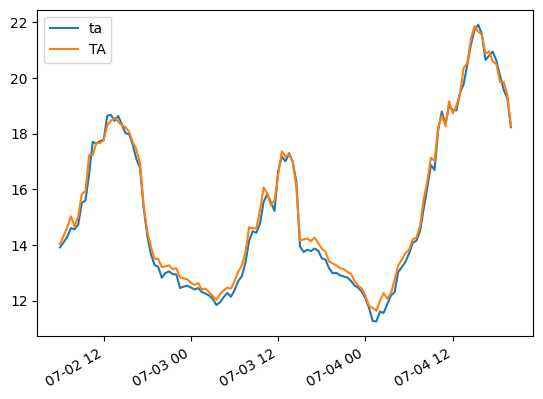

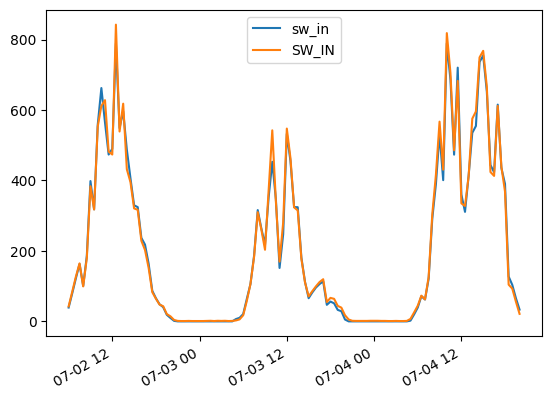

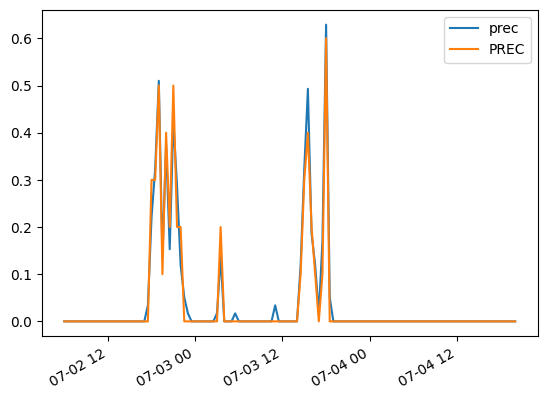

In [21]:
start_date = '2024-07-02 06:00'
end_date = '2024-07-04 20:00'
meteo_merged[start_date:end_date][['ta', 'TA']].plot(x_compat=True);
meteo_merged[start_date:end_date][['sw_in', 'SW_IN']].plot(x_compat=True);
meteo_merged[start_date:end_date][['prec', 'PREC']].plot(x_compat=True);

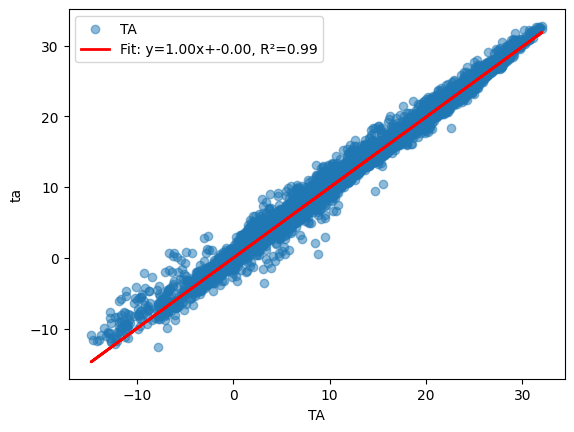

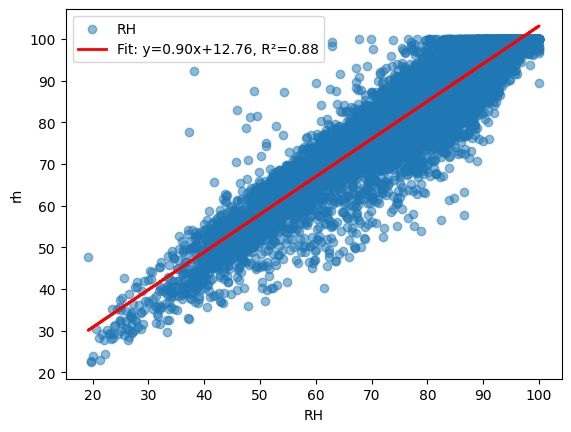

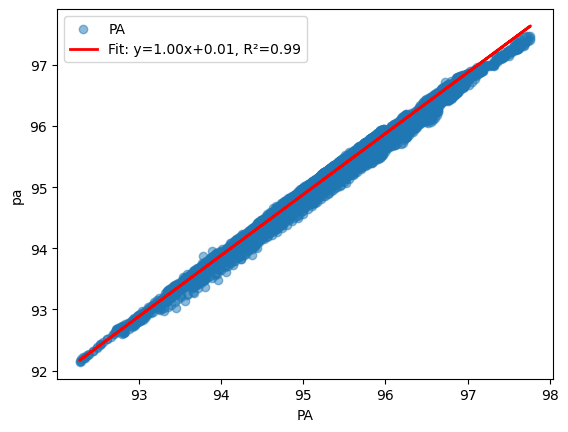

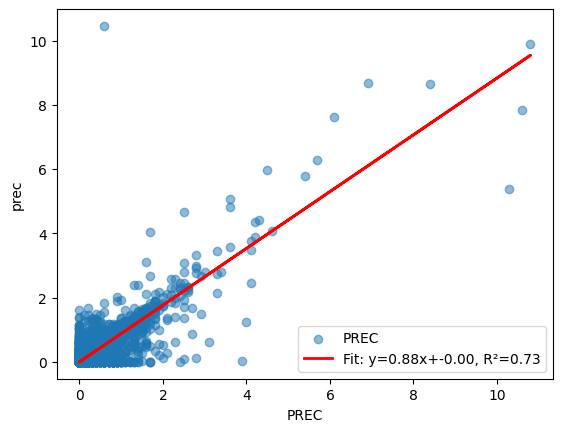

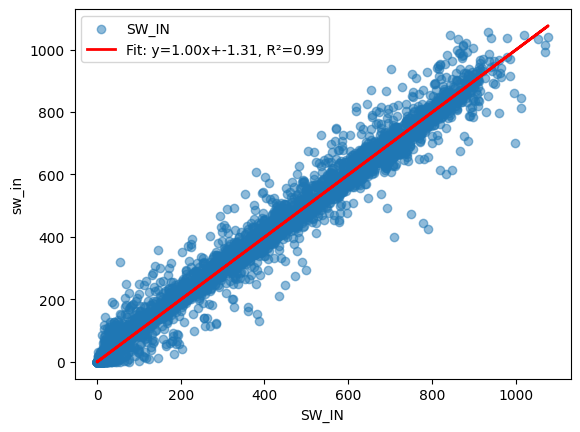

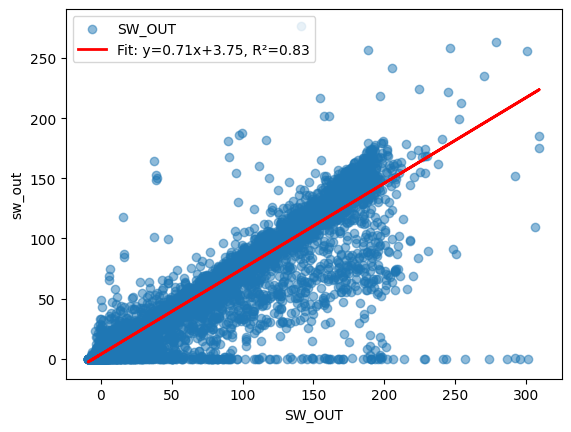

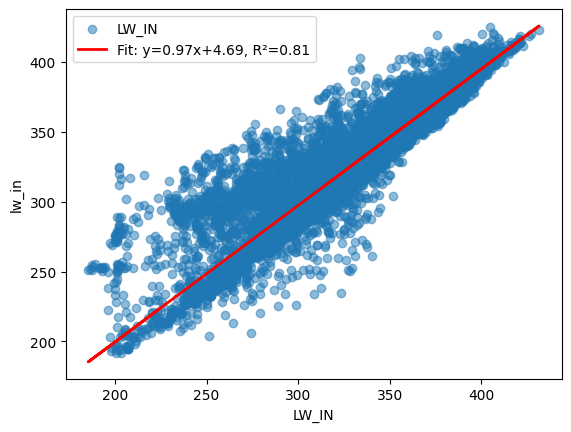

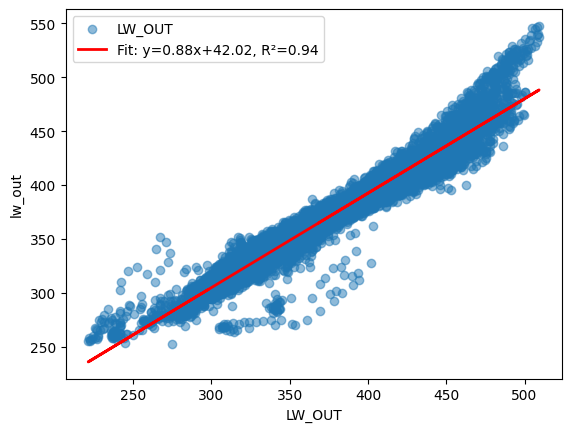

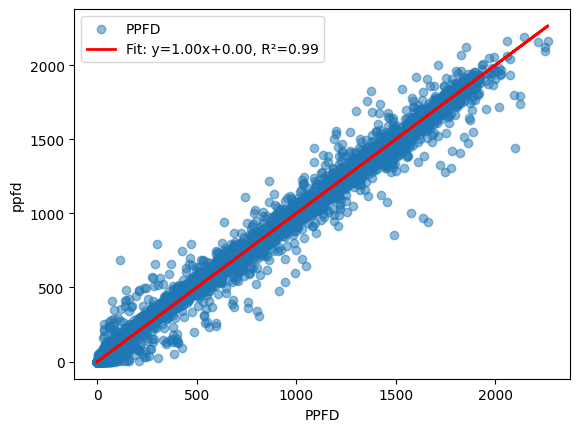

In [22]:
meteoswiss_vars = meteoswiss.columns.tolist()

for var in meteoswiss_vars:
    x = meteo_merged[var].values.reshape(-1, 1)
    y = meteo_merged[var.lower()].values

    # Drop NaNs
    mask = ~np.isnan(x.flatten()) & ~np.isnan(y)
    x, y = x[mask], y[mask]

    # Fit robust regression
    model = HuberRegressor().fit(x, y)
    y_pred = model.predict(x)

    # Equation and R²
    slope = model.coef_[0]
    intercept = model.intercept_
    r2 = r2_score(y, y_pred)

    # Plot
    plt.scatter(x, y, alpha=0.5, label=var)
    plt.plot(x, y_pred, color="red", lw=2, label=f"Fit: y={slope:.2f}x+{intercept:.2f}, R²={r2:.2f}")
    plt.xlabel(var)
    plt.ylabel(var.lower())
    plt.legend()
    plt.show()

# GAP-FILLING

Remaining NaNs per column:
g                       2645
pa                         0
ppfd                       0
prec                       0
rh                         0
swc_0.05                4070
swc_0.15                3402
swc_0.3                 3402
swc_0.05_soilvue        4402
swc_0.1_soilvue         4402
swc_0.2_soilvue         4556
swc_0.3_soilvue         4402
swc_0.4_soilvue         4402
swc_0.5_soilvue         4402
ta                         0
ts_0.05                 4070
ts_0.15                 4070
ts_0.3                  4070
ts_0.05_soilvue         4036
ts_0.1_soilvue          4036
ts_0.2_soilvue          4036
ts_0.3_soilvue          4036
ts_0.4_soilvue          4036
ts_0.5_soilvue          4036
sw_in                      0
sw_out                     0
lw_in                     94
lw_out                    94
TA                         0
RH                         0
PA                         0
PREC                       0
SW_IN                      0
SW_OUT          

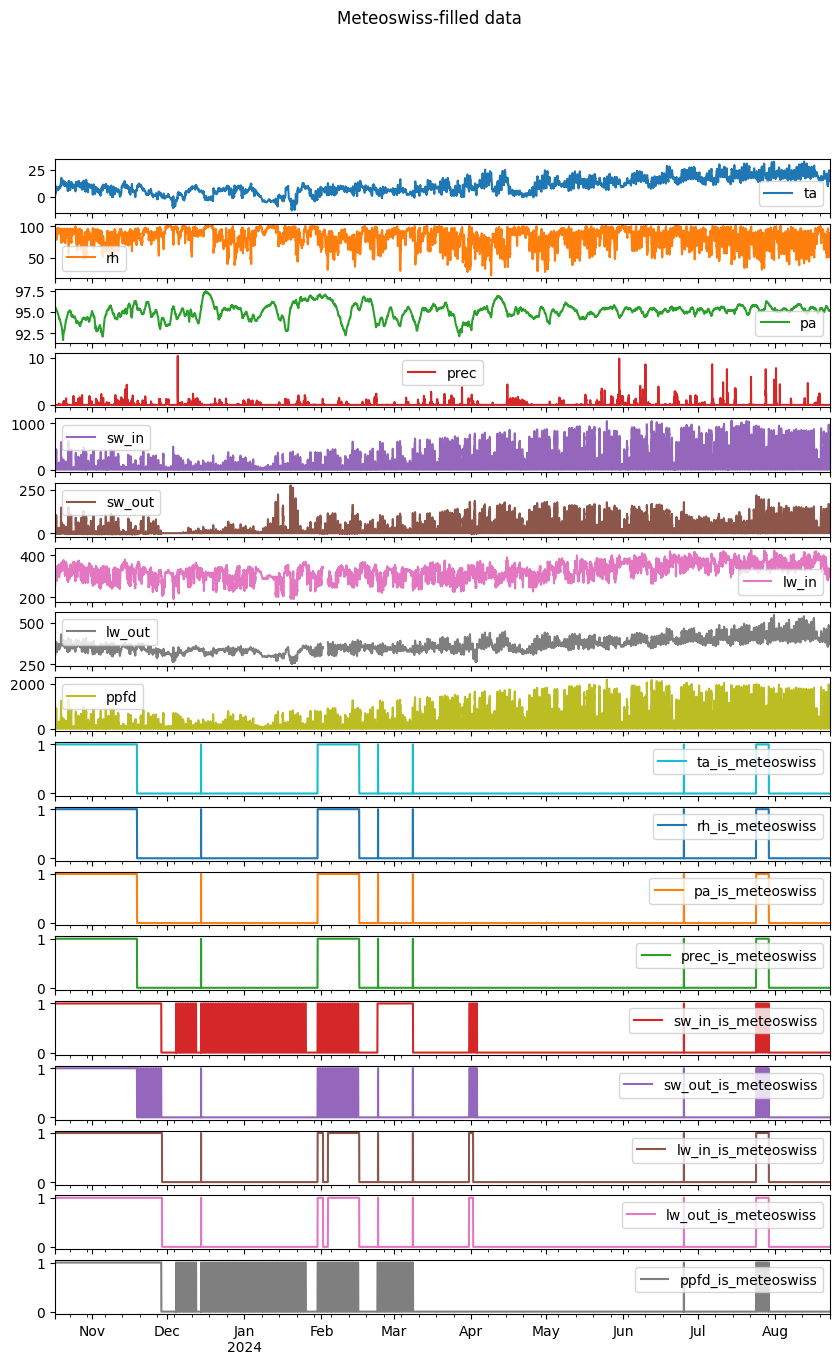

In [23]:
# Initialize a copy of the merged DataFrame to fill missing values
meteo_filled = meteo_merged.copy()

for var in meteoswiss_vars:
    lower_var = var.lower()
    flag_name = f"{lower_var}_is_meteoswiss"

    # Initialize flag column as False
    meteo_filled[flag_name] = 0

    # Values to fill (only where meteo_filled is NaN and meteoswiss has data)
    fill_mask = meteo_filled[lower_var].isna() & meteoswiss[var].notna()

    # Fill values
    meteo_filled.loc[fill_mask, lower_var] = meteoswiss.loc[fill_mask, var]

    # Mark fills
    meteo_filled.loc[fill_mask, flag_name] = 1

# Check remaining missing values
print("Remaining NaNs per column:")
print(meteo_filled.isna().sum())

# Select only the variables that exist in both datasets
cols_meteo_filled = [c.lower() for c in meteoswiss_vars]
flags = [c for c in meteo_filled.columns if c.endswith('_is_meteoswiss')]
to_plot = cols_meteo_filled + flags

meteo_filled[to_plot].plot(
    subplots=True, 
    figsize=(10, 15), 
    title='Meteoswiss-filled data'
);

# EXPORT GAP-FILLED DATA

In [24]:
meteo_filled.drop(columns=meteoswiss_vars, inplace=True)  # Drop the columns used for filling

# EXPORT GAP-FILLED DATA
# This is the input file of the published dataset (contains MeteoSwiss data, flagged in *_is_meteoswiss; Source: MeteoSwiss)
output_file = DATA_DIR / 'METEO' / 'CH-TAN_meteo_gapfilled-meteoswiss_2023-24.csv'
meteo_filled.reset_index(names='TIMESTAMP_END').to_csv(output_file, index=False)
print(f"Gap-filled data exported to {output_file}")

Gap-filled data exported to \\hest.nas.ethz.ch\green_groups_gl_processing\CH-TAN_Taenikon\20_ec_fluxes\PI_2023-2025\dataset_ch-tan_wheat_2023-24_flux_product\data\METEO\CH-TAN_meteo_gapfilled-meteoswiss_2023-24.csv


# End of notebook

In [25]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-09-17 17:25:04
